# Lab 05 — Robotics: Sensor-to-Action Control

A SCITOS G5 robot must convert
24 ultrasonic readings into one of four wall-following actions. The lab derives a compact,
auditable threshold-rule controller from four sensors and compares it with a stronger
all-sensor reference model.

**How to run.** Open this notebook from the `all_experiments` folder and choose *Run All*.
Evidence is written to `results/lab05/`.

**Questions**

1. Inspect the data and fix the split.
2. Select four sensors using training data only.
3. Fit an interpretable rule controller.
4. Fit a reference model.
5. Evaluate on the held-out data.
6. Test robustness to sensor noise.

## Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text

ROOT = Path.cwd().parent
DATA = ROOT / "all_datasets"
RESULTS = ROOT / "results" / "lab05"
RESULTS.mkdir(parents=True, exist_ok=True)

## Question 1 — Inspect the data and fix the split

The CSV has no header: 24 ultrasonic distances (metres) followed by the action label. Name
the columns, report the class balance and sensor summary statistics, and create a fixed
stratified 70/30 train/test split with seed 42. Save the split.

In [2]:
sensors = [f"US{i:02d}" for i in range(24)]
df = pd.read_csv(DATA / "lab05-sensor_readings_24.csv", header=None, names=sensors + ["action"])
X = df[sensors]
y = df.action

print("Shape:", df.shape)
display(y.value_counts().rename("count").to_frame().assign(share=lambda t: (t["count"] / len(df)).round(3)))
display(X.describe().T[["mean", "std", "min", "max"]].round(2).head(6))

train_idx, test_idx = train_test_split(df.index, test_size=0.30, random_state=42, stratify=y)
split = pd.Series("train", index=df.index, name="split")
split[test_idx] = "test"
split.rename_axis("row_id").to_csv(RESULTS / "split.csv")
print({"train": len(train_idx), "test": len(test_idx)})

Shape: (5456, 25)


,count,share
action,,
Move-Forward,2205,0.404
Sharp-Right-Turn,2097,0.384
Slight-Right-Turn,826,0.151
Slight-Left-Turn,328,0.060


,mean,std,min,max
US00,1.47,0.80,0.40,5.00
US01,2.33,1.41,0.44,5.03
US02,2.49,1.25,0.47,5.03
US03,2.80,1.31,0.83,5.02
US04,2.96,1.34,1.12,5.00
US05,2.89,1.28,1.11,5.00


{'train': 3819, 'test': 1637}


**Answer.** 5,456 readings; the classes are imbalanced (Move-Forward 40 %, Sharp-Right-Turn
38 %, Slight-Right-Turn 15 %, Slight-Left-Turn 6 %), so accuracy alone would flatter a
model that ignores the small classes — macro F1 is reported throughout. Sensor readings are
distances in metres between 0.4 m and 5 m. Stratification keeps the class shares
equal in the 3,819 training and 1,637 test rows.

## Question 2 — Select four sensors using training data only

Rank the 24 sensors by mutual information with the action, computed on the training rows
only, and keep the top four for the interpretable controller. Save the full ranking.

In [3]:
mi = mutual_info_classif(X.loc[train_idx], y[train_idx], random_state=42)
feature_table = pd.DataFrame({"sensor": sensors, "mutual_information": mi}).sort_values("mutual_information", ascending=False)
feature_table.to_csv(RESULTS / "feature_scores.csv", index=False)
selected = feature_table.sensor.head(4).tolist()
print("Selected sensors:", selected)
display(feature_table.head(8).round(3))

Selected sensors: ['US14', 'US17', 'US18', 'US13']


,sensor,mutual_information
14,US14,0.596
17,US17,0.508
18,US18,0.452
13,US13,0.417
19,US19,0.414
22,US22,0.386
5,US05,0.376
12,US12,0.375


**Answer.** The four most informative sensors are US14, US17, US18 and US13 — four
sensors from the same short arc of the ring, which is what a wall-follower needs: the
distance to the wall it is tracking, seen from slightly different angles. Selecting on
training rows only keeps the test set untouched.

## Question 3 — Fit an interpretable rule controller

A shallow decision tree is a fixed set of threshold rules. Carve an internal validation set
out of the training rows, choose the tree depth by validation macro F1, refit on all training
rows, and export the final tree as explicit if–then rules.

In [4]:
subtrain_idx, val_idx = train_test_split(train_idx, test_size=0.20, random_state=42, stratify=y[train_idx])

depth_results = []
for depth in [2, 3, 4, 5, 6]:
    candidate = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=20, class_weight="balanced", random_state=42)
    candidate.fit(X.loc[subtrain_idx, selected], y[subtrain_idx])
    score = f1_score(y[val_idx], candidate.predict(X.loc[val_idx, selected]), average="macro")
    depth_results.append({"max_depth": depth, "validation_macro_f1": score})
depth_table = pd.DataFrame(depth_results)
display(depth_table.round(3))

best_depth = int(depth_table.loc[depth_table.validation_macro_f1.idxmax(), "max_depth"])
rule_model = DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=20, class_weight="balanced", random_state=42)
rule_model.fit(X.loc[train_idx, selected], y[train_idx])

rules = export_text(rule_model, feature_names=selected)
(RESULTS / "rule_controller.txt").write_text(rules)
print("Selected depth:", best_depth, "| leaves:", rule_model.get_n_leaves())
print(rules)

,max_depth,validation_macro_f1
0,2,0.463
1,3,0.826
2,4,0.872
3,5,0.887
4,6,0.883


Selected depth: 5 | leaves: 14
|--- US14 <= 0.90
|   |--- class: Sharp-Right-Turn
|--- US14 >  0.90
|   |--- US18 <= 1.00
|   |   |--- US18 <= 0.50
|   |   |   |--- US13 <= 1.20
|   |   |   |   |--- class: Sharp-Right-Turn
|   |   |   |--- US13 >  1.20
|   |   |   |   |--- US18 <= 0.50
|   |   |   |   |   |--- class: Slight-Right-Turn
|   |   |   |   |--- US18 >  0.50
|   |   |   |   |   |--- class: Slight-Right-Turn
|   |   |--- US18 >  0.50
|   |   |   |--- US13 <= 0.90
|   |   |   |   |--- class: Sharp-Right-Turn
|   |   |   |--- US13 >  0.90
|   |   |   |   |--- US17 <= 0.49
|   |   |   |   |   |--- class: Slight-Right-Turn
|   |   |   |   |--- US17 >  0.49
|   |   |   |   |   |--- class: Move-Forward
|   |--- US18 >  1.00
|   |   |--- US17 <= 0.90
|   |   |   |--- US17 <= 0.79
|   |   |   |   |--- US13 <= 1.41
|   |   |   |   |   |--- class: Move-Forward
|   |   |   |   |--- US13 >  1.41
|   |   |   |   |   |--- class: Move-Forward
|   |   |   |--- US17 >  0.79
|   |   |   |   |--

**Answer.** Validation macro F1 climbs steeply from depth 2 to 4 and flattens at depth 5,
which is selected. The exported tree reads as a policy: the very first split — *if the
wall-side sensor US14 reads less than 0.9 m, turn sharply right* — is the
wall-following reflex, and the deeper splits refine the slight turns. Every decision is a
threshold a robotics engineer can inspect.

## Question 4 — Fit a reference model

Train a random forest on all 24 sensors using the same training partition. It is not
interpretable; its purpose is to show what accuracy the four-sensor rule controller gives up.

In [5]:
reference = RandomForestClassifier(
    n_estimators=200, min_samples_leaf=2, class_weight="balanced_subsample", random_state=42, n_jobs=-1
).fit(X.loc[train_idx], y[train_idx])
print("Random forest trained on", reference.n_features_in_, "sensors with", reference.n_estimators, "trees")

Random forest trained on 24 sensors with 200 trees


**Answer.** The forest uses every sensor and 200 trees, so it can exploit interactions the
shallow tree cannot. It is the reference ceiling, not a candidate controller.

## Question 5 — Evaluate on the held-out data

Report accuracy, macro precision, macro recall and macro F1 for both models on the test
rows, draw both confusion matrices, list per-class recall for the rule controller, and
identify its hardest action.

,model,accuracy,macro_precision,macro_recall,macro_f1
0,Interpretable rule tree,0.923,0.879,0.921,0.895
1,Random-forest reference,0.995,0.993,0.992,0.992


,precision,recall,f1
Move-Forward,0.907,0.943,0.924
Sharp-Right-Turn,1.000,0.913,0.954
Slight-Left-Turn,0.702,0.939,0.803
Slight-Right-Turn,0.906,0.891,0.898


Hardest action for the rule controller (lowest recall): Slight-Right-Turn


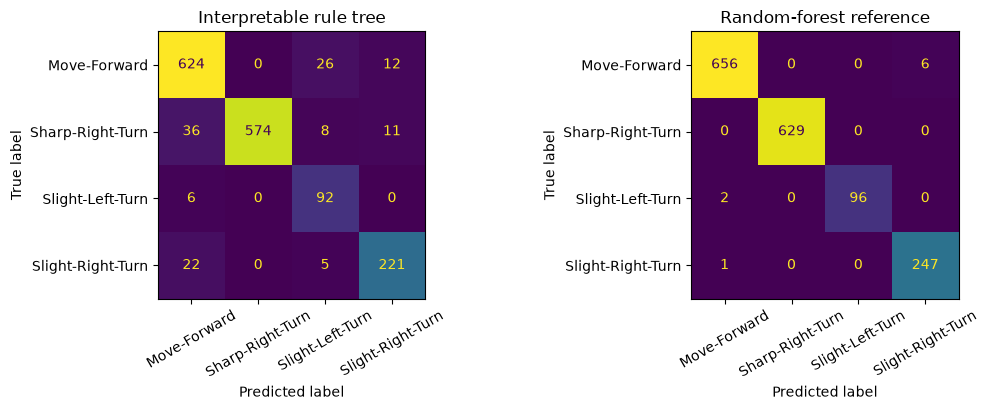

In [6]:
y_test = y[test_idx]
predictions = {"Interpretable rule tree": rule_model.predict(X.loc[test_idx, selected]),
               "Random-forest reference": reference.predict(X.loc[test_idx])}

rows = []
for name, prediction in predictions.items():
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, prediction, average="macro")
    rows.append({"model": name, "accuracy": accuracy_score(y_test, prediction),
                 "macro_precision": precision, "macro_recall": recall, "macro_f1": f1})
metrics = pd.DataFrame(rows)
metrics.to_csv(RESULTS / "metrics.csv", index=False)
display(metrics.round(3))

labels = sorted(y.unique())
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (name, prediction) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, prediction, labels=labels), display_labels=labels).plot(ax=ax, colorbar=False, xticks_rotation=30)
    ax.set_title(name)
plt.tight_layout()
plt.savefig(RESULTS / "confusion_matrices.png", dpi=160)

precision, recall, f1, _ = precision_recall_fscore_support(y_test, predictions["Interpretable rule tree"], labels=labels)
per_class = pd.DataFrame({"precision": precision, "recall": recall, "f1": f1}, index=labels)
per_class.to_csv(RESULTS / "rule_per_class.csv")
display(per_class.round(3))
print("Hardest action for the rule controller (lowest recall):", per_class.recall.idxmin())

**Answer.** The four-sensor tree reaches about 92 % accuracy and 0.90 macro F1; the
all-sensor forest reaches over 99 % on both. The rule controller's weakest action is
Slight-Right-Turn: it is confused with its neighbours Move-Forward and Sharp-Right-Turn,
because a "slight" turn is a narrow band of distances between the other two. That is the
accuracy cost of a controller a person can read.

## Question 6 — Test robustness to sensor noise

Add zero-mean Gaussian noise to the test readings at 2 %, 5 % and 10 % of the
training-set standard deviation of each selected sensor, and plot the rule controller's
macro F1 against the noise level.

,noise_fraction_of_train_sd,macro_f1
0,0.00,0.895
1,0.02,0.858
2,0.05,0.787
3,0.10,0.706


Saved: ['confusion_matrices.png', 'feature_scores.csv', 'metrics.csv', 'noise_robustness.csv', 'noise_robustness.png', 'rule_controller.txt', 'rule_per_class.csv', 'split.csv']


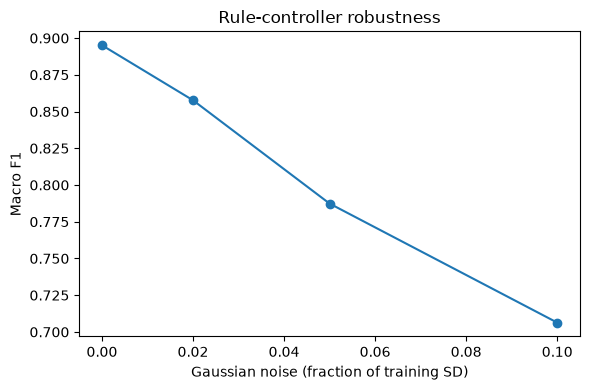

In [7]:
rng = np.random.default_rng(42)
train_sd = X.loc[train_idx, selected].std().to_numpy()
clean = X.loc[test_idx, selected].to_numpy(float)

noise_rows = []
for fraction in [0.0, 0.02, 0.05, 0.10]:
    noisy = clean + rng.normal(0.0, fraction * train_sd, size=clean.shape)
    prediction = rule_model.predict(pd.DataFrame(noisy, columns=selected))
    noise_rows.append({"noise_fraction_of_train_sd": fraction, "macro_f1": f1_score(y_test, prediction, average="macro")})
noise = pd.DataFrame(noise_rows)
noise.to_csv(RESULTS / "noise_robustness.csv", index=False)
display(noise.round(3))

ax = noise.plot(x="noise_fraction_of_train_sd", y="macro_f1", marker="o", legend=False, figsize=(6, 4))
ax.set(xlabel="Gaussian noise (fraction of training SD)", ylabel="Macro F1", title="Rule-controller robustness")
plt.tight_layout()
plt.savefig(RESULTS / "noise_robustness.png", dpi=160)
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))

**Answer.** Macro F1 falls from 0.90 with clean readings to about 0.71 at 10 % noise. Hard
thresholds are brittle: a reading that sits near a split boundary flips class as soon as
noise pushes it across. Offline classification accuracy is not the same as safe control —
deployment adds sequential feedback, actuator delay and sensor failure — so the tree is a
perception-policy prototype, not deployment-ready autonomy.